Using device: cpu


100%|██████████| 170M/170M [00:04<00:00, 41.4MB/s]



Training with lambda = 1e-05
Epoch 1: Loss = 9.5896
Epoch 2: Loss = 8.1846
Epoch 3: Loss = 7.0960
Epoch 4: Loss = 6.2221
Epoch 5: Loss = 5.5299
Final Accuracy: 54.43%
Sparsity: 0.04%


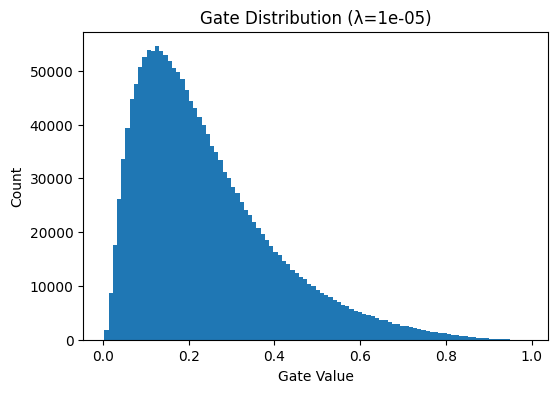


Training with lambda = 0.0001
Epoch 1: Loss = 80.1822
Epoch 2: Loss = 66.6640
Epoch 3: Loss = 54.3848
Epoch 4: Loss = 43.7743
Epoch 5: Loss = 35.0659
Final Accuracy: 54.40%
Sparsity: 0.07%


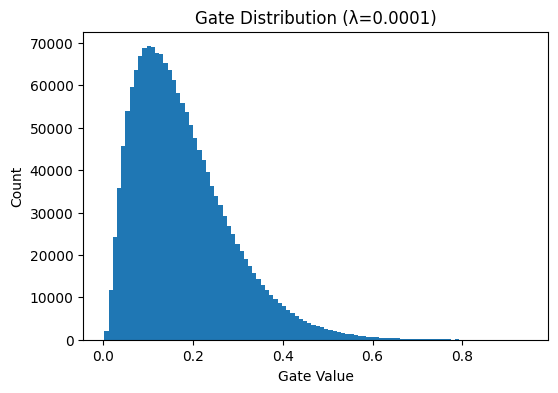


Training with lambda = 0.001
Epoch 1: Loss = 786.1383
Epoch 2: Loss = 652.2682
Epoch 3: Loss = 528.9517
Epoch 4: Loss = 421.4591
Epoch 5: Loss = 332.5194
Final Accuracy: 53.88%
Sparsity: 0.08%


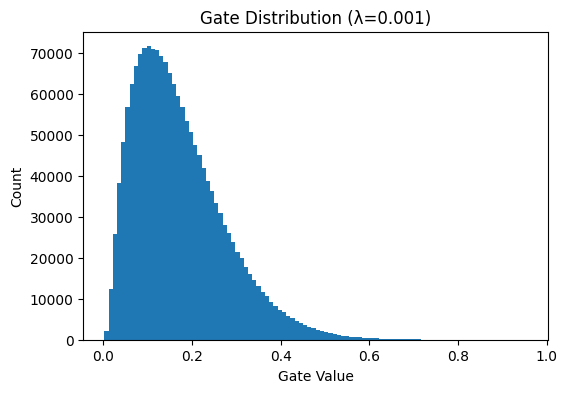


RESULTS TABLE
Lambda    Accuracy       Sparsity
--------------------------------------------------
1e-05     54.43%       0.04%
0.0001    54.40%       0.07%
0.001     53.88%       0.08%


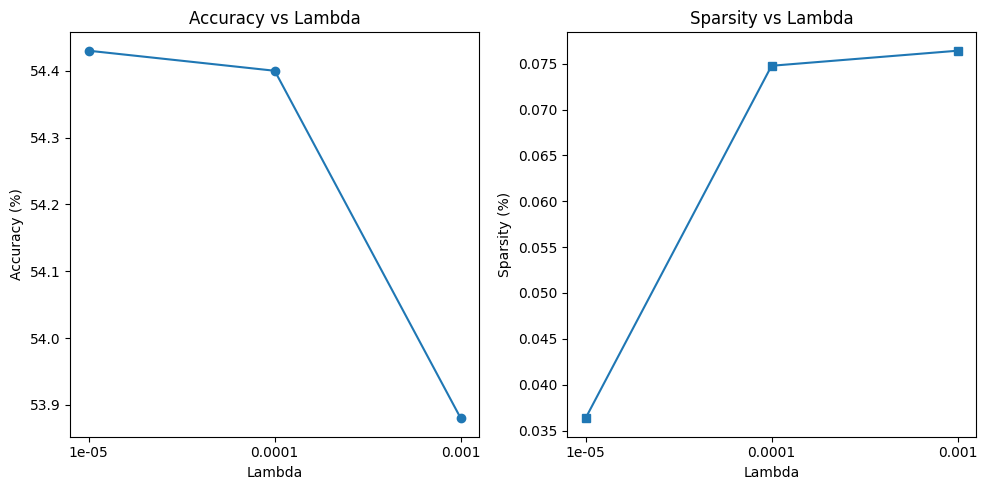

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

os.makedirs("results", exist_ok=True)


# =========================
# Prunable Linear Layer
# =========================
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)

    def get_gate_values(self):
        return torch.sigmoid(self.gate_scores)


# =========================
# Model
# =========================
class PrunableMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        gates = []
        for layer in [self.fc1, self.fc2, self.fc3]:
            gates.append(layer.get_gate_values().view(-1))
        return torch.cat(gates)


# =========================
# Sparsity Loss
# =========================
def compute_sparsity_loss(model):
    gates = model.get_all_gates()
    return torch.sum(gates)


# =========================
# Train
# =========================
def train_one_epoch(model, device, dataloader, optimizer, lambda_reg):
    model.train()
    running_loss = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        cls_loss = F.cross_entropy(outputs, labels)
        reg_loss = compute_sparsity_loss(model)

        total_loss = cls_loss + lambda_reg * reg_loss

        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()

    return running_loss / len(dataloader)


# =========================
# Evaluate
# =========================
def evaluate(model, device, dataloader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total


# =========================
# Sparsity %
# =========================
def compute_sparsity(model, threshold=1e-2):
    gates = model.get_all_gates()

    total = gates.numel()
    pruned = (gates < threshold).sum().item()

    return 100.0 * pruned / total


# =========================
# Plot: Gate Distribution (MANDATORY)
# =========================
def plot_gate_distribution(model, lam):
    gates = model.get_all_gates().cpu().detach().numpy()

    plt.figure(figsize=(6,4))
    plt.hist(gates, bins=100)
    plt.title(f"Gate Distribution (λ={lam})")
    plt.xlabel("Gate Value")
    plt.ylabel("Count")

    plt.savefig(f"results/gate_dist_{lam}.png")
    plt.show()


# =========================
# Plot: Summary Graphs
# =========================
def plot_results(results):
    lambdas = [str(r[0]) for r in results]
    accs = [r[1] for r in results]
    sparsities = [r[2] for r in results]

    plt.figure(figsize=(10,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(lambdas, accs, marker='o')
    plt.title("Accuracy vs Lambda")
    plt.xlabel("Lambda")
    plt.ylabel("Accuracy (%)")

    # Sparsity
    plt.subplot(1,2,2)
    plt.plot(lambdas, sparsities, marker='s')
    plt.title("Sparsity vs Lambda")
    plt.xlabel("Lambda")
    plt.ylabel("Sparsity (%)")

    plt.tight_layout()
    plt.savefig("results/summary.png")
    plt.show()


# =========================
# MAIN
# =========================
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])

    train_dataset = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

    # KEEPING YOUR ORIGINAL LAMBDAS
    lambda_values = [1e-5, 1e-4, 1e-3]

    results = []

    for lam in lambda_values:
        print("\n" + "="*50)
        print(f"Training with lambda = {lam}")
        print("="*50)

        model = PrunableMLP().to(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)

        for epoch in range(5):
            loss = train_one_epoch(model, device, train_loader, optimizer, lam)
            print(f"Epoch {epoch+1}: Loss = {loss:.4f}")

        acc = evaluate(model, device, test_loader)
        sparsity = compute_sparsity(model)

        print(f"Final Accuracy: {acc*100:.2f}%")
        print(f"Sparsity: {sparsity:.2f}%")

        # Store results
        results.append((lam, acc*100, sparsity))

        # MANDATORY plot
        plot_gate_distribution(model, lam)

    # =========================
    # Results Table
    # =========================
    print("\nRESULTS TABLE")
    print("="*50)
    print(f"{'Lambda':<10}{'Accuracy':<15}{'Sparsity'}")
    print("-"*50)

    for lam, acc, sp in results:
        print(f"{lam:<10}{acc:.2f}%       {sp:.2f}%")

    print("="*50)

    # Summary plots
    plot_results(results)


if __name__ == "__main__":
    main()